# 04 — N-gram Multiclass Classification

## BI-RADS Mammography Report Classification

### Objective

This notebook performs multiclass BI-RADS classification using the
class-conditional N-gram language models constructed in Notebook 03.

The N-gram models are evaluated independently at three orders:

- Unigram (order = 1)
- Bigram (order = 2)
- Trigram (order = 3)

For each report, the class-conditional log-likelihood is combined
with the training-set class prior using Maximum A Posteriori (MAP)
classification:

$$
\hat{y}
=
\arg\max_c
\left[
\log P(x \mid c) + \log P(c)
\right]
$$

where:

- $x$ = mammography report
- $c$ = BI-RADS class
- $P(x \mid c)$ = N-gram language-model likelihood
- $P(c)$ = training-set class prior

### Inputs

This notebook consumes the artifacts produced by:

`03_ngram_preprocessing_smoothing.ipynb`

and the existing train/validation/test splits.

### Outputs

This notebook produces:

1. Predictions for unigram, bigram and trigram models
2. Accuracy and class-balanced evaluation metrics
3. Per-class precision, recall and F1
4. Confusion matrices
5. Prediction/error-analysis files
6. N-gram order comparison results
7. Computational efficiency measurements
8. Final artifacts for comparison with classical ML and DL models

In [43]:
# 1. Imports and Reproducibility

import os
import sys
import json
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print(f"Random state: {RANDOM_STATE}")

Libraries imported successfully.
Random state: 42


In [45]:
# 2. Google Drive and Project Configuration

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
# 3. Project Paths and Experimental Configuration

# ============================================================
# PROJECT ROOT
# ============================================================

BASE_DIR = Path('/content/drive/MyDrive/NLP_Research_Project')

# ============================================================
# DATA
# ============================================================

SPLITS_DIR = BASE_DIR / 'data' / 'splits'

TRAIN_PATH = SPLITS_DIR / 'train.csv'
VAL_PATH = SPLITS_DIR / 'validation.csv'
TEST_PATH = SPLITS_DIR / 'test.csv'

# ============================================================
# N-GRAM ARTIFACTS
# ============================================================

ARTIFACT_DIR = BASE_DIR / 'artifacts' / 'ngram'

ARTIFACT_PATH = ARTIFACT_DIR / 'ngram_language_models.joblib'
VOCABULARY_PATH = ARTIFACT_DIR / 'shared_vocabulary.json'
METADATA_PATH = ARTIFACT_DIR / 'ngram_metadata.json'

# Shared utility module
SRC_DIR = BASE_DIR / 'src'

# ============================================================
# RESULTS
# ============================================================

RESULTS_DIR = BASE_DIR / 'results'

NGRAM_RESULTS_DIR = RESULTS_DIR / 'ngram'
NGRAM_METRICS_DIR = RESULTS_DIR / 'metrics'
NGRAM_PREDICTIONS_DIR = RESULTS_DIR / 'predictions'
NGRAM_CM_DIR = RESULTS_DIR / 'confusion_matrices'
NGRAM_ERROR_DIR = RESULTS_DIR / 'error_analysis'

for directory in [
    NGRAM_RESULTS_DIR,
    NGRAM_METRICS_DIR,
    NGRAM_PREDICTIONS_DIR,
    NGRAM_CM_DIR,
    NGRAM_ERROR_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:")
print(BASE_DIR)

print("\nArtifact directory:")
print(ARTIFACT_DIR)

print("\nResults directory:")
print(NGRAM_RESULTS_DIR)

BASE_DIR:
/content/drive/MyDrive/NLP_Research_Project

Artifact directory:
/content/drive/MyDrive/NLP_Research_Project/artifacts/ngram

Results directory:
/content/drive/MyDrive/NLP_Research_Project/results/ngram


In [47]:
## 4. Verify Required Inputs

'''
Before running the classification experiments, verify that all
required data splits and N-gram artifacts are available.
'''

required_files = {
    "Train split": TRAIN_PATH,
    "Validation split": VAL_PATH,
    "Test split": TEST_PATH,
    "N-gram language models": ARTIFACT_PATH,
    "Shared vocabulary": VOCABULARY_PATH,
    "N-gram metadata": METADATA_PATH,
    "Shared N-gram utility": SRC_DIR / 'ngram_utils.py'
}

verification = []

for name, path in required_files.items():
    verification.append({
        "File": name,
        "Path": str(path),
        "Exists": path.exists()
    })

verification_df = pd.DataFrame(verification)

display(verification_df)

if not verification_df["Exists"].all():
    missing = verification_df.loc[
        ~verification_df["Exists"], "File"
    ].tolist()

    raise FileNotFoundError(
        f"Missing required inputs: {missing}"
    )

print("\nAll required inputs are available.")

,File,Path,Exists
0,Train split,/content/drive/MyDrive/NLP_Research_Project/da...,True
1,Validation split,/content/drive/MyDrive/NLP_Research_Project/da...,True
2,Test split,/content/drive/MyDrive/NLP_Research_Project/da...,True
3,N-gram language models,/content/drive/MyDrive/NLP_Research_Project/ar...,True
4,Shared vocabulary,/content/drive/MyDrive/NLP_Research_Project/ar...,True
5,N-gram metadata,/content/drive/MyDrive/NLP_Research_Project/ar...,True
6,Shared N-gram utility,/content/drive/MyDrive/NLP_Research_Project/sr...,True



All required inputs are available.


## 5. Load Existing Train, Validation and Test Splits

The splits are not recreated in this notebook.

The training split was used by Notebook 03 to construct the
class-conditional N-gram models.

Validation and test data are used only for classification and
evaluation here.

In [48]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

ID_COLUMN = 'id'
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'label'

required_columns = {
    ID_COLUMN,
    TEXT_COLUMN,
    LABEL_COLUMN
}

for name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():

    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"{name} is missing columns: {missing}"
        )

    if df[TEXT_COLUMN].isna().any():
        raise ValueError(
            f"{name} contains missing text values."
        )

    if df[LABEL_COLUMN].isna().any():
        raise ValueError(
            f"{name} contains missing labels."
        )

print(f"Train:       {train_df.shape}")
print(f"Validation:  {val_df.shape}")
print(f"Test:        {test_df.shape}")

print("\nClasses:")
print(sorted(train_df[LABEL_COLUMN].unique()))

Train:       (6425, 4)
Validation:  (1377, 4)
Test:        (1377, 4)

Classes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## 6. Class Distribution

The BI-RADS classification task is strongly imbalanced.

The distribution is reported here to provide context for the
class-balanced evaluation metrics used later.

In [49]:
class_distribution = pd.DataFrame({
    "Train": train_df[LABEL_COLUMN].value_counts().sort_index(),
    "Validation": val_df[LABEL_COLUMN].value_counts().sort_index(),
    "Test": test_df[LABEL_COLUMN].value_counts().sort_index()
}).fillna(0).astype(int)

display(class_distribution)

,Train,Validation,Test
label,,,
0,423,91,91
1,176,38,38
2,5126,1098,1099
3,498,107,106
4,150,32,32
5,20,4,5
6,32,7,6


## 7. Load the N-gram Scoring Module

Notebook 03 exports a shared `NGramScorer`.

The scorer internally handles:

- shared vocabulary
- `<UNK>` mapping
- unigram probability
- Kneser-Ney bigram probability
- Kneser-Ney trigram probability
- lower-order backoff
- report boundary handling

This notebook does not reconstruct any of those components.

In [50]:
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from ngram_utils import tokenize, NGramScorer

scorer = NGramScorer(str(ARTIFACT_PATH))

print("NGramScorer loaded successfully.")

NGramScorer loaded successfully.


In [51]:
## 8. Verify N-gram Model Metadata

with open(METADATA_PATH, 'r') as f:
    ngram_metadata = json.load(f)

display(pd.Series(ngram_metadata))

,0
input,data/splits/train.csv
validation,data/splits/validation.csv
test,data/splits/test.csv
tokenizer_pattern,[a-z0-9]+(?:[./-][a-z0-9]+)*
min_token_frequency,2
unknown_token,<UNK>
boundary_tokens,"[<BOS>, <EOS>]"
unigram,"add-alpha, alpha=1.0"
bigram,interpolated Kneser-Ney
trigram,interpolated Kneser-Ney with bigram backoff


## 9. Scorer Interface Sanity Check

Before performing full-dataset inference, verify that the shared
scorer produces finite log-likelihoods for all seven BI-RADS classes
at all three N-gram orders.

In [52]:
sample_text = val_df.iloc[0][TEXT_COLUMN]

tokens = tokenize(sample_text)

print("Sample ID:", val_df.iloc[0][ID_COLUMN])
print("\nFirst 30 tokens:")
print(tokens[:30])

print("\nScores:")

for order in [1, 2, 3]:

    print(f"\nN-gram order = {order}")

    for class_label in range(7):

        score = scorer.score(
            tokens,
            class_label,
            order
        )

        print(
            f"Class {class_label}: "
            f"{score:.4f}"
        )

Sample ID: Acc3390

First 30 tokens:
['clinical', 'indication', 'tracking', 'findings', 'partially', 'liposubstituted', 'breasts', 'no', 'grouped', 'pleomorphic', 'microcalcifications', 'were', 'observed', 'sparse', 'calcifications', 'bilateral', 'intramammary', 'lymph', 'nodes', 'the', 'axillary', 'regions', 'do', 'not', 'present', 'significant', 'changes', 'comparative', 'analysis', 'regarding']

Scores:

N-gram order = 1
Class 0: -178.4397
Class 1: -170.0428
Class 2: -159.9585
Class 3: -175.5788
Class 4: -186.3243
Class 5: -211.2003
Class 6: -204.4025

N-gram order = 2
Class 0: -52.1101
Class 1: -71.9052
Class 2: -40.9590
Class 3: -44.5344
Class 4: -62.6041
Class 5: -125.7460
Class 6: -85.5692

N-gram order = 3
Class 0: -45.4982
Class 1: -74.0251
Class 2: -26.9885
Class 3: -30.0046
Class 4: -52.5020
Class 5: -129.2434
Class 6: -78.2419


## 10. MAP-Based Multiclass N-gram Classifier

For each report, the class-conditional N-gram language model produces:

$$
\log P(x \mid c)
$$

for each BI-RADS class $c \in \{0,\ldots,6\}$.

The class prior is then incorporated using Maximum A Posteriori (MAP)
classification:

$$
\log P(c \mid x)
\propto
\log P(x \mid c) + \log P(c)
$$

Therefore, the predicted class is:

$$
\hat{c}
=
\arg\max_c
\left[
\log P(x \mid c) + \log P(c)
\right]
$$

The same classifier is used for all three N-gram orders:

- order = 1 → Unigram
- order = 2 → Bigram
- order = 3 → Trigram

The underlying N-gram models and smoothing are not reconstructed here;
they are loaded from the artifacts produced by Notebook 03.

In [53]:
# ============================================================
# MAP MULTICLASS N-GRAM CLASSIFIER
# ============================================================

CLASSES = list(range(7))
NGRAM_ORDERS = [1, 2, 3]


def predict_report(text, order, return_scores=False):
    """
    Predict the BI-RADS class of a single report using
    MAP classification.

    Parameters
    ----------
    text : str
        Preprocessed mammography report.

    order : int
        N-gram order:
        1 = unigram
        2 = bigram
        3 = trigram

    return_scores : bool
        If True, also return class-wise likelihood and
        posterior scores.

    Returns
    -------
    predicted_class : int
        Predicted BI-RADS class.

    scores : dict, optional
        Class-wise scoring information.
    """

    if order not in NGRAM_ORDERS:
        raise ValueError(
            f"Invalid N-gram order: {order}. "
            f"Expected one of {NGRAM_ORDERS}."
        )

    # Shared tokenizer from Notebook 03
    tokens = tokenize(text)

    class_scores = {}

    for class_label in CLASSES:

        # log P(x | class)
        log_likelihood = scorer.score(
            tokens,
            class_label,
            order
        )

        # log P(class)
        log_prior = scorer.log_prior(class_label)

        # MAP score:
        # log P(x | class) + log P(class)
        map_score = log_likelihood + log_prior

        class_scores[class_label] = {
            "log_likelihood": log_likelihood,
            "log_prior": log_prior,
            "map_score": map_score
        }

    # Choose class with maximum MAP score
    predicted_class = max(
        class_scores,
        key=lambda c: class_scores[c]["map_score"]
    )

    if return_scores:
        return predicted_class, class_scores

    return predicted_class

## 11. Single-Report Classification Demonstration

Before running the complete validation and test sets, a single report
is classified against all seven BI-RADS classes.

This provides a transparent sanity check of the MAP decision process.

In [59]:
# Select one validation report
sample_row = val_df.iloc[0]

sample_id = sample_row[ID_COLUMN]
sample_text = sample_row[TEXT_COLUMN]
actual_class = int(sample_row[LABEL_COLUMN])

print("Sample ID:", sample_id)
print("Actual BI-RADS class:", actual_class)

predicted_class, sample_scores = predict_report(
    sample_text,
    order=3,
    return_scores=True
)

print("\nPredicted BI-RADS class:", predicted_class)


# Create a clean score table
score_table = pd.DataFrame([
    {
        "BI-RADS Class": int(class_label),
        "Log Likelihood": values["log_likelihood"],
        "Log Prior": values["log_prior"],
        "MAP Score": values["map_score"]
    }
    for class_label, values in sample_scores.items()
])

score_table = score_table.sort_values(
    "BI-RADS Class"
).reset_index(drop=True)

display(
    score_table.style.format({
        "Log Likelihood": "{:.4f}",
        "Log Prior": "{:.4f}",
        "MAP Score": "{:.4f}"
    })
)

Sample ID: Acc3390
Actual BI-RADS class: 2

Predicted BI-RADS class: 2


,BI-RADS Class,Log Likelihood,Log Prior,MAP Score
0,0,-45.4982,-2.7206,-48.2188
1,1,-74.0251,-3.5975,-77.6225
2,2,-26.9885,-0.2259,-27.2144
3,3,-30.0046,-2.5574,-32.5620
4,4,-52.5020,-3.7573,-56.2593
5,5,-129.2434,-5.7722,-135.0156
6,6,-78.2419,-5.3022,-83.5441


In [60]:
## 11.1 MAP Decision Verification

# The predicted class must correspond to the BI-RADS class having the maximum MAP score.

best_class_from_scores = int(
    score_table.loc[
        score_table["MAP Score"].idxmax(),
        "BI-RADS Class"
    ]
)

print("Predicted class:", predicted_class)
print("Maximum MAP-score class:", best_class_from_scores)

assert predicted_class == best_class_from_scores

print("\nMAP decision verified successfully.")

Predicted class: 2
Maximum MAP-score class: 2

MAP decision verified successfully.


## 12. Verify Training Class Priors

The MAP classifier uses the class priors estimated from the training
data used to construct the N-gram models.

The priors are inspected here to verify that all seven BI-RADS classes
are represented and that the values are finite.

In [61]:
prior_table = pd.DataFrame({
    "Class": CLASSES,
    "Log Prior": [
        scorer.log_prior(c)
        for c in CLASSES
    ]
})

prior_table["Prior"] = np.exp(
    prior_table["Log Prior"]
)

display(prior_table)

print(
    "Sum of priors:",
    prior_table["Prior"].sum()
)

,Class,Log Prior,Prior
0,0,-2.720580,0.065837
1,1,-3.597468,0.027393
2,2,-0.225871,0.797821
3,3,-2.557352,0.077510
4,4,-3.757317,0.023346
5,5,-5.772220,0.003113
6,6,-5.302216,0.004981


Sum of priors: 1.0


## 13. Dataset-Level N-gram Prediction

The following function applies the MAP classifier to every report in
a dataset.

For each report it records:

- report ID
- true BI-RADS class
- predicted BI-RADS class
- MAP score for each BI-RADS class
- N-gram order
- inference time

The same function is used for validation and test data.

In [62]:
def predict_dataset(df, order):
    """
    Run MAP-based N-gram classification on an entire dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing ID, text and label columns.

    order : int
        N-gram order (1, 2 or 3).

    Returns
    -------
    predictions_df : pandas.DataFrame
        Report-level predictions and class scores.
    """

    records = []

    start_time = time.perf_counter()

    for _, row in df.iterrows():

        report_id = row[ID_COLUMN]
        text = row[TEXT_COLUMN]
        true_label = int(row[LABEL_COLUMN])

        prediction, scores = predict_report(
            text,
            order,
            return_scores=True
        )

        record = {
            "id": report_id,
            "true_label": true_label,
            "predicted_label": prediction,
            "order": order
        }

        # Store class-wise MAP scores
        for class_label in CLASSES:
            record[f"map_score_{class_label}"] = (
                scores[class_label]["map_score"]
            )

        records.append(record)

    elapsed_time = time.perf_counter() - start_time

    predictions_df = pd.DataFrame(records)

    return predictions_df, elapsed_time

## 14. Small-Batch Prediction Sanity Check

A five-report subset is classified first to verify:

- prediction count
- prediction labels
- ID alignment
- true-label alignment
- class-score columns

In [64]:
test_sample = val_df.head(5)

small_predictions, elapsed = predict_dataset(
    test_sample,
    order=3
)

print(f"Elapsed time: {elapsed:.3f} seconds")
print(f"Predictions generated: {len(small_predictions)}")

display(small_predictions)


assert len(small_predictions) == len(test_sample)

assert small_predictions["id"].tolist() == \
       test_sample["id"].tolist()

assert small_predictions["true_label"].tolist() == \
       test_sample[LABEL_COLUMN].astype(int).tolist()

assert small_predictions["predicted_label"].isin(CLASSES).all()

print("All small-batch sanity checks passed.")

Elapsed time: 0.019 seconds
Predictions generated: 5


,id,true_label,predicted_label,order,map_score_0,map_score_1,map_score_2,map_score_3,map_score_4,map_score_5,map_score_6
0,Acc3390,2,2,3,-48.218824,-77.622530,-27.214402,-32.561989,-56.259318,-135.015614,-83.544130
1,Acc2398,2,2,3,-42.604009,-55.153844,-23.728437,-29.761309,-51.613049,-156.934950,-109.765143
2,Acc12998,2,2,3,-54.468778,-136.325184,-35.053464,-51.685736,-39.384709,-104.020342,-100.704562
3,Acc6936,2,2,3,-47.813138,-91.452030,-24.531848,-49.229094,-54.314201,-94.401988,-64.029927
4,Acc11306,2,2,3,-31.719868,-42.465371,-10.751836,-34.944097,-31.173334,-62.298383,-45.094679


All small-batch sanity checks passed.


## 15. Evaluation Metrics

The N-gram classifier is evaluated using the same metrics that will
later be used for comparison with the classical ML and deep-learning
models.

Because the BI-RADS classes are imbalanced, Macro-F1 is treated as the
primary metric.

Additional metrics include:

- Accuracy
- Macro Precision
- Macro Recall
- Weighted F1

Per-class precision, recall and F1 are retained for detailed analysis.

In [65]:
def evaluate_predictions(predictions_df):
    """
    Calculate classification metrics from a prediction DataFrame.
    """

    y_true = predictions_df["true_label"]
    y_pred = predictions_df["predicted_label"]

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),

        "Macro Precision": precision_score(
            y_true,
            y_pred,
            labels=CLASSES,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_true,
            y_pred,
            labels=CLASSES,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            labels=CLASSES,
            average="macro",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_true,
            y_pred,
            labels=CLASSES,
            average="weighted",
            zero_division=0
        )
    }

    return metrics

## 16. Validation Experiment — Unigram

The validation set is classified using the unigram language models
(order = 1).

No model parameters are changed during this step.

In [66]:
val_unigram_pred, unigram_time = predict_dataset(
    val_df,
    order=1
)

unigram_metrics = evaluate_predictions(
    val_unigram_pred
)

print("Unigram validation completed.")
print(f"Inference time: {unigram_time:.2f} seconds")
print(f"Reports classified: {len(val_unigram_pred)}")

display(
    pd.DataFrame([unigram_metrics])
)

Unigram validation completed.
Inference time: 0.86 seconds
Reports classified: 1377


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,0.769063,0.394263,0.433498,0.383757,0.784128


## 17. Validation Experiment — Bigram

The validation set is classified using the smoothed bigram language
models (order = 2).

In [67]:
val_bigram_pred, bigram_time = predict_dataset(
    val_df,
    order=2
)

bigram_metrics = evaluate_predictions(
    val_bigram_pred
)

print("Bigram validation completed.")
print(f"Inference time: {bigram_time:.2f} seconds")
print(f"Reports classified: {len(val_bigram_pred)}")

display(
    pd.DataFrame([bigram_metrics])
)

Bigram validation completed.
Inference time: 3.24 seconds
Reports classified: 1377


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,0.852578,0.626287,0.56333,0.584708,0.85194


## 18. Validation Experiment — Trigram

The validation set is classified using the smoothed trigram language
models (order = 3).

In [68]:
val_trigram_pred, trigram_time = predict_dataset(
    val_df,
    order=3
)

trigram_metrics = evaluate_predictions(
    val_trigram_pred
)

print("Trigram validation completed.")
print(f"Inference time: {trigram_time:.2f} seconds")
print(f"Reports classified: {len(val_trigram_pred)}")

display(
    pd.DataFrame([trigram_metrics])
)

Trigram validation completed.
Inference time: 7.47 seconds
Reports classified: 1377


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,0.847495,0.614209,0.539733,0.552098,0.843758


## 19. Validation Performance Comparison Across N-gram Orders

In [69]:
validation_results = pd.DataFrame([
    {
        "Model": "Unigram",
        "Order": 1,
        **unigram_metrics,
        "Inference Time (s)": unigram_time
    },
    {
        "Model": "Bigram",
        "Order": 2,
        **bigram_metrics,
        "Inference Time (s)": bigram_time
    },
    {
        "Model": "Trigram",
        "Order": 3,
        **trigram_metrics,
        "Inference Time (s)": trigram_time
    }
])

display(
    validation_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Inference Time (s)": "{:.2f}"
    })
)

,Model,Order,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Inference Time (s)
0,Unigram,1,0.7691,0.3943,0.4335,0.3838,0.7841,0.86
1,Bigram,2,0.8526,0.6263,0.5633,0.5847,0.8519,3.24
2,Trigram,3,0.8475,0.6142,0.5397,0.5521,0.8438,7.47


## 20. Best N-gram Order on Validation Data

The N-gram order with the highest validation Macro-F1 is identified as
the best-performing configuration for subsequent final evaluation.

In [70]:
best_order_row = validation_results.loc[
    validation_results["Macro F1"].idxmax()
]

best_order = int(best_order_row["Order"])

print("Best validation configuration:")
print(f"Model: {best_order_row['Model']}")
print(f"N-gram order: {best_order}")
print(f"Macro F1: {best_order_row['Macro F1']:.4f}")

Best validation configuration:
Model: Bigram
N-gram order: 2
Macro F1: 0.5847


In [72]:
# Save validation predictions

val_unigram_path = (
    NGRAM_PREDICTIONS_DIR / "validation_unigram_predictions.csv"
)

val_bigram_path = (
    NGRAM_PREDICTIONS_DIR / "validation_bigram_predictions.csv"
)

val_trigram_path = (
    NGRAM_PREDICTIONS_DIR / "validation_trigram_predictions.csv"
)

val_unigram_pred.to_csv(
    val_unigram_path,
    index=False
)

val_bigram_pred.to_csv(
    val_bigram_path,
    index=False
)

val_trigram_pred.to_csv(
    val_trigram_path,
    index=False
)

print("Validation prediction files saved:")
print(val_unigram_path)
print(val_bigram_path)
print(val_trigram_path)

Validation prediction files saved:
/content/drive/MyDrive/NLP_Research_Project/results/predictions/validation_unigram_predictions.csv
/content/drive/MyDrive/NLP_Research_Project/results/predictions/validation_bigram_predictions.csv
/content/drive/MyDrive/NLP_Research_Project/results/predictions/validation_trigram_predictions.csv


In [73]:
# Save the comparison table

validation_results_path = (
    NGRAM_METRICS_DIR / "ngram_validation_comparison.csv"
)

validation_results.to_csv(
    validation_results_path,
    index=False
)

print(
    f"Saved validation comparison to:\n"
    f"{validation_results_path}"
)

Saved validation comparison to:
/content/drive/MyDrive/NLP_Research_Project/results/metrics/ngram_validation_comparison.csv


## 23. Per-Class Validation Performance

Overall accuracy can hide poor performance on minority BI-RADS classes.

Therefore, precision, recall and F1 are calculated separately for
each BI-RADS category.

This analysis is particularly important for interpreting the
difference between Accuracy and Macro-F1.

In [74]:
def per_class_metrics(predictions_df):

    report = classification_report(
        predictions_df["true_label"],
        predictions_df["predicted_label"],
        labels=CLASSES,
        target_names=[f"BI-RADS {c}" for c in CLASSES],
        output_dict=True,
        zero_division=0
    )

    rows = []

    for class_label in CLASSES:

        class_name = f"BI-RADS {class_label}"

        rows.append({
            "Class": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1": report[class_name]["f1-score"],
            "Support": int(report[class_name]["support"])
        })

    return pd.DataFrame(rows)

In [75]:
unigram_per_class = per_class_metrics(
    val_unigram_pred
)

bigram_per_class = per_class_metrics(
    val_bigram_pred
)

trigram_per_class = per_class_metrics(
    val_trigram_pred
)

In [76]:
## 25. Bigram Per-Class Validation Performance
display(
    bigram_per_class.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Class,Precision,Recall,F1,Support
0,BI-RADS 0,0.7465,0.5824,0.6543,91
1,BI-RADS 1,0.8636,0.5000,0.6333,38
2,BI-RADS 2,0.9183,0.9317,0.9250,1098
3,BI-RADS 3,0.4508,0.5140,0.4803,107
4,BI-RADS 4,0.5000,0.5938,0.5429,32
5,BI-RADS 5,0.3333,0.2500,0.2857,4
6,BI-RADS 6,0.5714,0.5714,0.5714,7


In [77]:
per_class_f1_comparison = pd.DataFrame({
    "Class": [f"BI-RADS {c}" for c in CLASSES],
    "Unigram F1": unigram_per_class["F1"].values,
    "Bigram F1": bigram_per_class["F1"].values,
    "Trigram F1": trigram_per_class["F1"].values
})

display(
    per_class_f1_comparison.style.format({
        "Unigram F1": "{:.4f}",
        "Bigram F1": "{:.4f}",
        "Trigram F1": "{:.4f}"
    })
)

,Class,Unigram F1,Bigram F1,Trigram F1
0,BI-RADS 0,0.5922,0.6543,0.6087
1,BI-RADS 1,0.1633,0.6333,0.5660
2,BI-RADS 2,0.8755,0.9250,0.9206
3,BI-RADS 3,0.3887,0.4803,0.4885
4,BI-RADS 4,0.4848,0.5429,0.5507
5,BI-RADS 5,0.0000,0.2857,0.2857
6,BI-RADS 6,0.1818,0.5714,0.4444


In [78]:
bigram_per_class.to_csv(
    NGRAM_METRICS_DIR / "validation_bigram_per_class.csv",
    index=False
)

unigram_per_class.to_csv(
    NGRAM_METRICS_DIR / "validation_unigram_per_class.csv",
    index=False
)

trigram_per_class.to_csv(
    NGRAM_METRICS_DIR / "validation_trigram_per_class.csv",
    index=False
)

per_class_f1_comparison.to_csv(
    NGRAM_METRICS_DIR / "validation_per_class_f1_comparison.csv",
    index=False
)

print("Per-class validation results saved.")

Per-class validation results saved.


## 28. Bigram Validation Confusion Matrix

The confusion matrix shows the distribution of true versus predicted
BI-RADS categories for the best-performing N-gram order on validation
data.

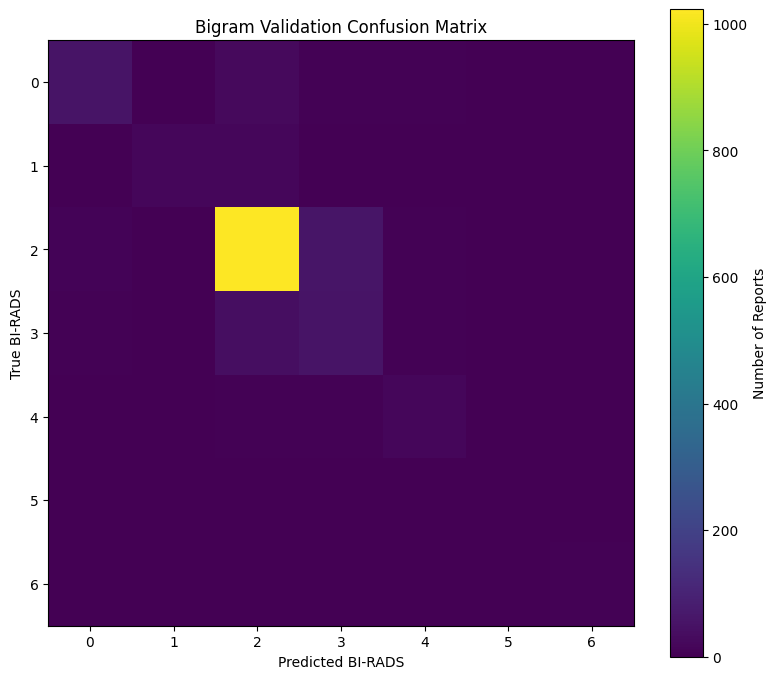

In [79]:
cm_bigram = confusion_matrix(
    val_bigram_pred["true_label"],
    val_bigram_pred["predicted_label"],
    labels=CLASSES
)

plt.figure(figsize=(8, 7))

plt.imshow(cm_bigram)

plt.xticks(
    range(len(CLASSES)),
    CLASSES
)

plt.yticks(
    range(len(CLASSES)),
    CLASSES
)

plt.xlabel("Predicted BI-RADS")
plt.ylabel("True BI-RADS")
plt.title("Bigram Validation Confusion Matrix")

plt.colorbar(label="Number of Reports")

plt.tight_layout()
plt.show()

In [80]:
np.savetxt(
    NGRAM_CM_DIR / "validation_bigram_confusion_matrix.csv",
    cm_bigram,
    delimiter=",",
    fmt="%d"
)

print("Bigram confusion matrix saved.")

Bigram confusion matrix saved.


## 30. Row-Normalized Bigram Confusion Matrix

Because the BI-RADS dataset is imbalanced, raw confusion-matrix counts
can be dominated by majority classes.

A row-normalized confusion matrix is therefore generated to show the
proportion of each true BI-RADS class assigned to each predicted class.

Each row sums to 100%.

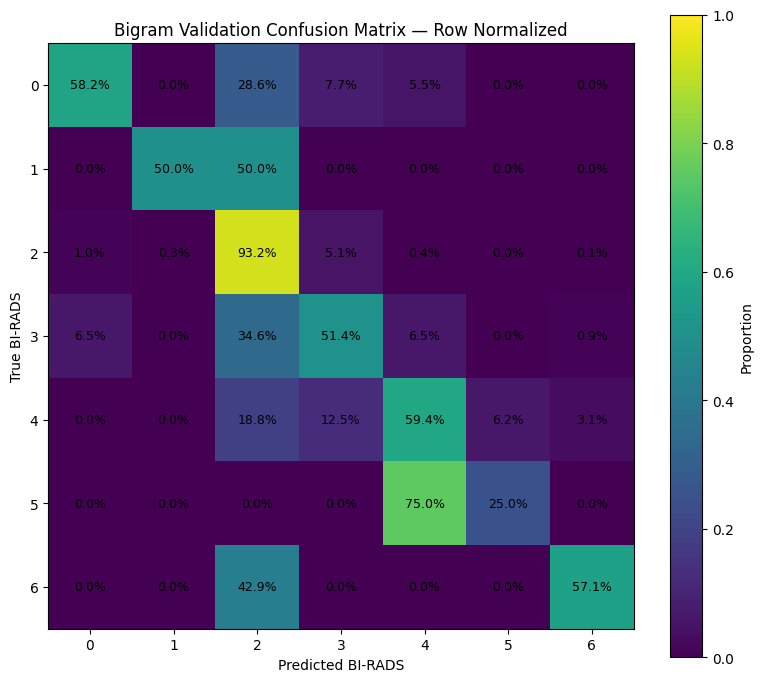

In [83]:
cm_bigram_normalized = (
    cm_bigram.astype(float)
    / cm_bigram.sum(axis=1, keepdims=True)
)

# Handle classes with zero samples safely
cm_bigram_normalized = np.nan_to_num(
    cm_bigram_normalized
)

plt.figure(figsize=(8, 7))

plt.imshow(cm_bigram_normalized, vmin=0, vmax=1)

plt.xticks(
    range(len(CLASSES)),
    CLASSES
)

plt.yticks(
    range(len(CLASSES)),
    CLASSES
)

plt.xlabel("Predicted BI-RADS")
plt.ylabel("True BI-RADS")
plt.title("Bigram Validation Confusion Matrix — Row Normalized")

plt.colorbar(label="Proportion")

# Add percentage values inside cells
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        plt.text(
            j,
            i,
            f"{cm_bigram_normalized[i, j] * 100:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [86]:
print("Validation class distribution:")
display(
    val_df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("BI-RADS")
    .reset_index(name="Count")
)

Validation class distribution:


,BI-RADS,Count
0,0,91
1,1,38
2,2,1098
3,3,107
4,4,32
5,5,4
6,6,7


In [85]:
print("\nValidation class distribution (%):")

display(
    (
        val_df["label"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
        .rename_axis("BI-RADS")
        .reset_index(name="Percentage")
    )
)


Validation class distribution (%):


,BI-RADS,Percentage
0,0,6.61
1,1,2.76
2,2,79.74
3,3,7.77
4,4,2.32
5,5,0.29
6,6,0.51


In [87]:
# Save normalized confusion matrix

normalized_cm_path = (
    NGRAM_CM_DIR / "validation_bigram_confusion_matrix_normalized.csv"
)

pd.DataFrame(
    cm_bigram_normalized,
    index=[f"BI-RADS {c}" for c in CLASSES],
    columns=[f"BI-RADS {c}" for c in CLASSES]
).to_csv(normalized_cm_path)

print(f"Saved normalized confusion matrix to:")
print(normalized_cm_path)

Saved normalized confusion matrix to:
/content/drive/MyDrive/NLP_Research_Project/results/confusion_matrices/validation_bigram_confusion_matrix_normalized.csv


## 34. Final Test Evaluation — Selected Bigram Model

Based on validation performance, the bigram model was selected as the
best N-gram configuration according to Macro-F1.

The model is now evaluated once on the held-out test set.

No model parameters, vocabulary, smoothing parameters, or decision
rules are modified using the test data.

The test set therefore provides the final unbiased estimate of the
selected N-gram classifier's performance.

In [88]:
# Final test evaluation

print("Running final Bigram evaluation on the held-out test set...")
print(f"Test samples: {len(test_df)}")

test_bigram_pred, test_bigram_time = predict_dataset(
    test_df,
    order=2
)

test_bigram_metrics = evaluate_predictions(
    test_bigram_pred
)

print("\nFinal Bigram test evaluation completed.")
print(f"Inference time: {test_bigram_time:.2f} seconds")
print(f"Reports classified: {len(test_bigram_pred)}")

display(
    pd.DataFrame([test_bigram_metrics]).style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Inference Time (s)": "{:.2f}"
    })
)

Running final Bigram evaluation on the held-out test set...
Test samples: 1377

Final Bigram test evaluation completed.
Inference time: 4.66 seconds
Reports classified: 1377


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,0.8569,0.6422,0.5772,0.5938,0.8596


## 35. Final Test Per-Class Performance

Per-class metrics are reported for the selected bigram classifier to
identify differences in classification performance across BI-RADS
categories.

In [89]:
# Test per-class metrics

test_bigram_per_class = per_class_metrics(
    test_bigram_pred
)

display(
    test_bigram_per_class.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Class,Precision,Recall,F1,Support
0,BI-RADS 0,0.7326,0.6923,0.7119,91
1,BI-RADS 1,0.8261,0.5000,0.6230,38
2,BI-RADS 2,0.9357,0.9272,0.9314,1099
3,BI-RADS 3,0.4109,0.5000,0.4511,106
4,BI-RADS 4,0.5238,0.6875,0.5946,32
5,BI-RADS 5,0.4000,0.4000,0.4000,5
6,BI-RADS 6,0.6667,0.3333,0.4444,6


## 36. Final Test Confusion Matrix

The confusion matrix shows the classification behaviour of the
selected bigram model on the held-out test set.

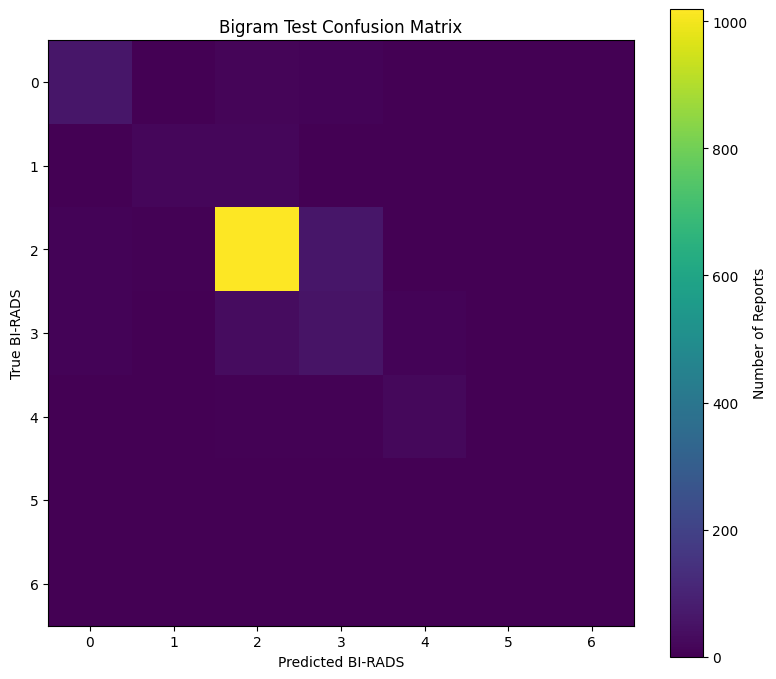

In [91]:
# Test confusion matrix

cm_test_bigram = confusion_matrix(
    test_bigram_pred["true_label"],
    test_bigram_pred["predicted_label"],
    labels=CLASSES
)

plt.figure(figsize=(8, 7))

plt.imshow(cm_test_bigram)

plt.xticks(
    range(len(CLASSES)),
    CLASSES
)

plt.yticks(
    range(len(CLASSES)),
    CLASSES
)

plt.xlabel("Predicted BI-RADS")
plt.ylabel("True BI-RADS")
plt.title("Bigram Test Confusion Matrix")

plt.colorbar(label="Number of Reports")

plt.tight_layout()
plt.show()

## 37. Row-Normalized Test Confusion Matrix

Because the dataset contains substantial class imbalance, a
row-normalized confusion matrix is provided alongside the raw-count
matrix.

Each row represents a true BI-RADS class and sums to 100%, allowing
classification behaviour to be compared across classes independently
of class frequency.

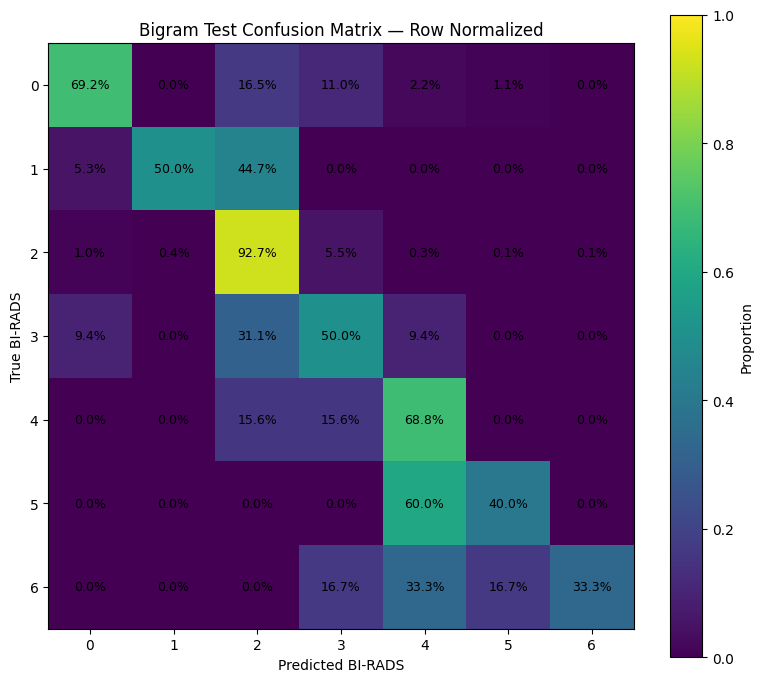

In [92]:
# Normalized test confusion matrix

cm_test_normalized = (
    cm_test_bigram.astype(float)
    / cm_test_bigram.sum(axis=1, keepdims=True)
)

cm_test_normalized = np.nan_to_num(
    cm_test_normalized
)

plt.figure(figsize=(8, 7))

plt.imshow(
    cm_test_normalized,
    vmin=0,
    vmax=1
)

plt.xticks(
    range(len(CLASSES)),
    CLASSES
)

plt.yticks(
    range(len(CLASSES)),
    CLASSES
)

plt.xlabel("Predicted BI-RADS")
plt.ylabel("True BI-RADS")
plt.title("Bigram Test Confusion Matrix — Row Normalized")

plt.colorbar(label="Proportion")

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        plt.text(
            j,
            i,
            f"{cm_test_normalized[i, j] * 100:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [93]:
# Save final test predictions and metrics

test_bigram_pred.to_csv(
    NGRAM_PREDICTIONS_DIR / "test_bigram_predictions.csv",
    index=False
)

pd.DataFrame([test_bigram_metrics]).to_csv(
    NGRAM_METRICS_DIR / "test_bigram_metrics.csv",
    index=False
)

test_bigram_per_class.to_csv(
    NGRAM_METRICS_DIR / "test_bigram_per_class.csv",
    index=False
)

pd.DataFrame(
    cm_test_bigram,
    index=[f"BI-RADS {c}" for c in CLASSES],
    columns=[f"BI-RADS {c}" for c in CLASSES]
).to_csv(
    NGRAM_CM_DIR / "test_bigram_confusion_matrix.csv"
)

pd.DataFrame(
    cm_test_normalized,
    index=[f"BI-RADS {c}" for c in CLASSES],
    columns=[f"BI-RADS {c}" for c in CLASSES]
).to_csv(
    NGRAM_CM_DIR / "test_bigram_confusion_matrix_normalized.csv"
)

print("Final Bigram test artifacts saved successfully.")

Final Bigram test artifacts saved successfully.


## 39. Final N-gram Experimental Summary

This table consolidates the validation comparison of all N-gram orders
with the final held-out test performance of the selected configuration.

In [94]:
final_ngram_summary = validation_results.copy()

final_ngram_summary["Selected"] = (
    final_ngram_summary["Order"] == best_order
)

display(
    final_ngram_summary.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Inference Time (s)": "{:.2f}"
    })
)

print("\nSelected model:")
print(f"N-gram order: {best_order}")

print("\nFinal held-out test performance:")
for metric, value in test_bigram_metrics.items():
    if metric != "Inference Time (s)":
        print(f"{metric}: {value:.4f}")

,Model,Order,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Inference Time (s),Selected
0,Unigram,1,0.7691,0.3943,0.4335,0.3838,0.7841,0.86,False
1,Bigram,2,0.8526,0.6263,0.5633,0.5847,0.8519,3.24,True
2,Trigram,3,0.8475,0.6142,0.5397,0.5521,0.8438,7.47,False



Selected model:
N-gram order: 2

Final held-out test performance:
Accuracy: 0.8569
Macro Precision: 0.6422
Macro Recall: 0.5772
Macro F1: 0.5938
Weighted F1: 0.8596


In [95]:
handoff_summary = {
    "Selected Model": "Kneser-Ney Bigram",
    "N-gram Order": 2,
    "Validation Macro F1": validation_results.loc[
        validation_results["Order"] == 2,
        "Macro F1"
    ].iloc[0],
    "Test Accuracy": test_bigram_metrics["Accuracy"],
    "Test Macro Precision": test_bigram_metrics["Macro Precision"],
    "Test Macro Recall": test_bigram_metrics["Macro Recall"],
    "Test Macro F1": test_bigram_metrics["Macro F1"],
    "Test Weighted F1": test_bigram_metrics["Weighted F1"],
    "Test Inference Time (s)": test_bigram_time
}

handoff_df = pd.DataFrame([handoff_summary])

handoff_path = (
    NGRAM_METRICS_DIR / "FINAL_NGRAM_HANDOFF.csv"
)

handoff_df.to_csv(
    handoff_path,
    index=False
)

display(
    handoff_df.style.format({
        "Validation Macro F1": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Test Macro Precision": "{:.4f}",
        "Test Macro Recall": "{:.4f}",
        "Test Macro F1": "{:.4f}",
        "Test Weighted F1": "{:.4f}",
        "Test Inference Time (s)": "{:.2f}"
    })
)

print(f"\nFinal handoff file saved to:\n{handoff_path}")

,Selected Model,N-gram Order,Validation Macro F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Weighted F1,Test Inference Time (s)
0,Kneser-Ney Bigram,2,0.5847,0.8569,0.6422,0.5772,0.5938,0.8596,4.66



Final handoff file saved to:
/content/drive/MyDrive/NLP_Research_Project/results/metrics/FINAL_NGRAM_HANDOFF.csv
